# 01. Exploratory Data Analysis: rJokes dataset

Goal: understand the data before training anything. I am looking for:
- How is `score` distributed?
- How long are jokes, and does length relate to score?
- Is raw score usable directly, or does it need transforming?

In [2]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data import load_split
from config import FIG_DIR

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 100)

In [3]:
train = load_split("train")
dev = load_split("dev")
test = load_split("test")

print(f"train: {len(train):,} rows")
print(f"dev:   {len(dev):,} rows")
print(f"test:  {len(test):,} rows")
train.head()

train: 345,846 rows
dev:   43,233 rows
test:  43,233 rows


,score,joke
0,5,How do you end two deaf persons' arguing? Switch off the light.
1,1,"What does a blonde have in common with a hurricane? First there’s a lot of suckin and blowin, th..."
2,2,I went to a white pride parade the other day. The floats just kept going around in circles about...
3,1,Georgia and Alabama hate each other Really we have very similar jokes for each other. In Georgia...
4,0,Going to make an app. I've decided to create an app where you tour museums and art galleries fin...


## The target label (already log-scaled)

Important: the `score` column is not the raw Reddit score. The dataset
authors already applied `round(ln(raw_score + 1))`, giving discrete integer
labels 0–11 (raw Reddit scores go into the millions and these don't). So we do
not log-transform it again during modeling. Below we view it two ways:
as the 0–11 regression target and bucketed into humor classes.

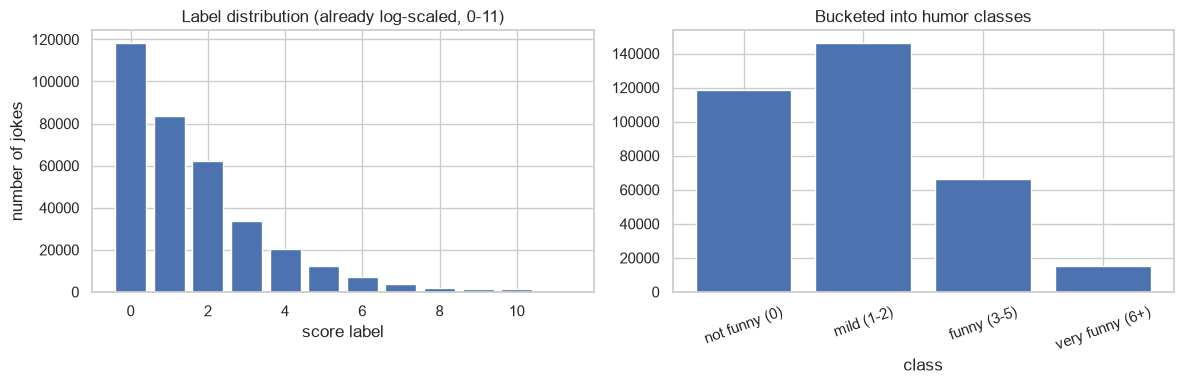

count    345846.000000
mean          1.618174
std           1.824897
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          11.000000
Name: score, dtype: float64

Class balance (fraction):
score
not funny (0)      0.342
mild (1-2)         0.423
funny (3-5)        0.192
very funny (6+)    0.044
Name: count, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = train["score"].value_counts().sort_index()
axes[0].bar(counts.index, counts.values)
axes[0].set_title("Label distribution (already log-scaled, 0-11)")
axes[0].set_xlabel("score label")
axes[0].set_ylabel("number of jokes")

def to_bucket(s):
    if s == 0:
        return "not funny (0)"
    elif s <= 2:
        return "mild (1-2)"
    elif s <= 5:
        return "funny (3-5)"
    else:
        return "very funny (6+)"

order = ["not funny (0)", "mild (1-2)", "funny (3-5)", "very funny (6+)"]
buckets = train["score"].map(to_bucket).value_counts().reindex(order)
axes[1].bar(buckets.index, buckets.values)
axes[1].set_title("Bucketed into humor classes")
axes[1].set_xlabel("class")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(train["score"].describe())
print("\nClass balance (fraction):")
print((buckets / buckets.sum()).round(3))

## Joke length vs. score

Does length correlate with score at all? Useful to know before everything is attributed to "humor" when it might be length/format.

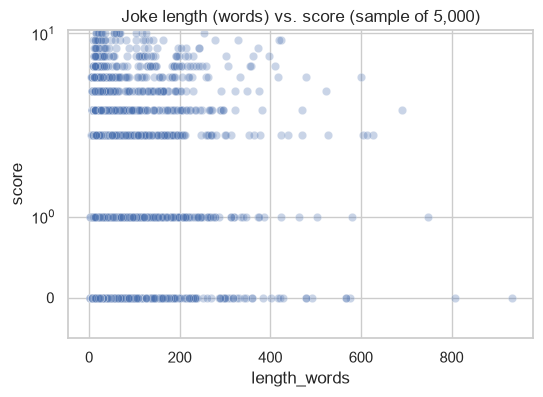

              length_words     score
length_words      1.000000  0.130194
score             0.130194  1.000000


In [5]:
train["length_chars"] = train["joke"].str.len()
train["length_words"] = train["joke"].str.split().str.len()

fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(
    data=train.sample(5000, random_state=0),
    x="length_words",
    y="score",
    alpha=0.3,
    ax=ax,
)
ax.set_yscale("symlog")
ax.set_title("Joke length (words) vs. score (sample of 5,000)")
plt.savefig(FIG_DIR / "02_joke_length_vs_score.png", dpi=150, bbox_inches="tight")
plt.show()

print(train[["length_words", "score"]].corr())

## Top and bottom scoring jokes

Sanity check: do high-score jokes actually look funnier than low-score
ones, or is score dominated by noise?

In [7]:
print("Top 5 by score")
for j in train.nlargest(5, "score")["joke"]:
    print("-", j)

print("\nBottom 5 by score")
for j in train.nsmallest(5, "score")["joke"]:
    print("-", j)

Top 5 by score
- Call me a racist if you want, but south of the border is a sea of violence, corruption and stupidity I wouldn't touch with a ten foot pole. I just thank my lucky stars I live in Canada.  Edit: Sorry.
- Do you want to know why the republicans won't impeach Trump? Because they believe in carrying a baby to full term.
- A wife decides to take her husband, Dave, to a strip club for his birthday. They arrive at the club and the doorman says, "Hey, Dave! How ya doin'?"  His wife is puzzled and asks if hes been to this club before.  "Oh no," says Dave. "Hes on my bowling team."  When they are seated, a waitress asks Dave if hed like his usual and brings over a Budweiser.  His wife is becoming increasingly uncomfortable and says,"How did she know that you drink Budweiser?"  "Shes in the Ladies Bowling League, honey. We share lanes with them."  A stripper then comes over to their table, throws her arms around Dave, and says "Hi Davey. Want your usual table dance, big boy?"  Dav